In [3]:
from manim import *

# 3. Object Orientation

As Python allows, OOP is also possible in *manim*. It can help with the codes structure, reuseability --- or in your case --- with distributing work between project members.<br>

In [46]:
# name of the class (inherits from Mobjects mother class)
class Timeline(Mobject):
	# constructor method
	def __init__(self, center = [0, 0, 0], x_range = [0, 10.9, 1], length = 8, **kwargs):
		super().__init__(**kwargs)

		# number line
		self.number_line = NumberLine(x_range = x_range, length = length, include_numbers = True, include_tip = True).move_to(center)
		number_line_label = Tex(r"$t$", font_size = 48).next_to(self.number_line).shift(0.5*UP)
		self.add(self.number_line, number_line_label)



	# method to get an event on the timeline
	def get_event(self, time, descriptor):
		# get the coordinate for the given time
		c_of_time = self.number_line.n2p(time)
		# define the mobjects that are to be added
		event_dot = Dot(radius = 0.1, color = RED).move_to(c_of_time)
		event_connector = DashedLine(start = c_of_time, end = c_of_time + 2*UP, color = RED)
		event_description = Text(f"{descriptor}", font_size = 48, color = RED).scale(0.5).move_to(c_of_time + 2.5*UP)

		# return all the mobjects summed to a group
		event_group = VGroup(event_dot, event_connector, event_description)
		return event_group

As you can now see, the actual code in the timeline_Scene class is much sleeker and readable.

Manim Community v0.19.0

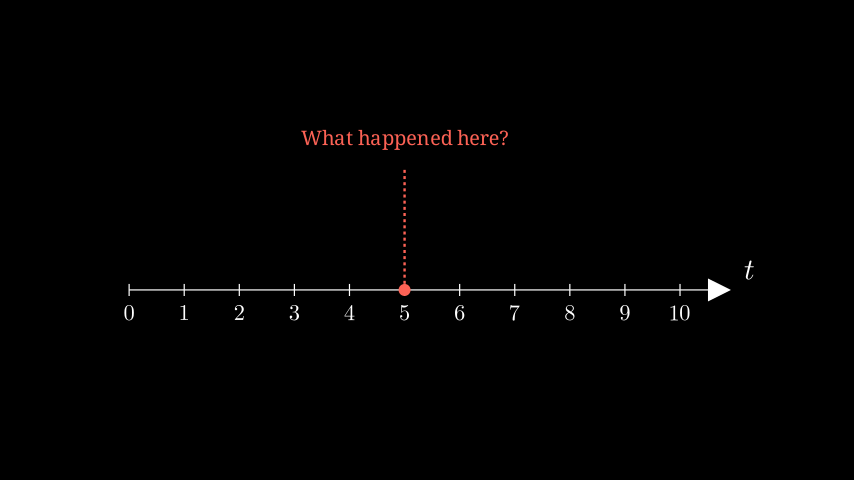

In [47]:
%%manim -ql --fps 60 -v WARNING --disable_caching timeline_Scene


class timeline_Scene(Scene):
	def construct(self):
		# timeline
		timeline = Timeline(center = DOWN, length = 10)
		self.add(timeline)

		# event
		event = timeline.get_event(5, "What happened here?")
		self.add(event)

> ### +++ Your Turn: OOP in *manim* +++
>
> Source your coordinate system from the previous notebook out into a class in a different notebook cell!<br>
> *Advice: Use the following structure for your class:*
> - The coordinate system and its labels are within the ``__init__`` constructor.
> - There is a method ``get_dot`` called with internal coordinates returning the dot.
> - A method ``get_plot`` returns the plot for a given function x(t) defined from origin to the given t value.

In [1]:
# Your turn